In [11]:
import pandas as pd

metabolomics = pd.read_csv("../data/metabolomics/Metabolomics_maaslined_norun.csv")

metabolomics.head()


,Unnamed: 0,SAM000203_tp1,SAM000269_tp1,SAM000268_tp1,SAM000266_tp1,SAM000257_tp1,SAM000260_tp1,SAM000259_tp1,SAM000253_tp1,SAM000254_tp1,...,SAM000536_tp2,SAM000529_tp2,SAM000283_tp3,SAM000500_tp2,SAM000250_tp3,SAM000306_tp3,SAM000309_tp3,SAM000470_tp2,SAM000458_tp2,SAM000304_tp3
0,S-1-pyrroline-5-carboxylate,0.733745,1.476325,1.411830,0.566404,1.481165,0.496603,1.168407,0.585473,0.964275,...,0.824462,0.928435,1.713793,0.723486,1.169712,0.839558,0.916199,0.482881,0.813109,0.171151
1,1-methylnicotinamide,0.382365,0.387559,1.383625,0.840769,0.846519,0.478453,0.768354,0.928184,0.700113,...,1.223317,1.011842,1.056749,0.498745,0.967518,0.982720,0.677429,1.120531,0.817388,2.692711
2,alpha-ketoglutarate,0.847127,0.342713,0.350704,0.464346,0.483156,0.431380,0.382185,0.400653,0.608075,...,0.308320,0.374151,0.330072,0.313287,0.345309,0.353886,0.486239,0.438559,0.555517,0.329638
3,3-hydroxyisobutyrate,0.442159,0.488864,0.187794,1.405387,0.437858,1.225215,0.608739,0.072016,0.072016,...,0.756751,0.072016,1.162334,0.971753,0.072016,0.072016,1.301529,0.072016,0.072016,0.072016
4,3-hydroxy-3-methylglutarate,0.784203,0.907234,1.005262,1.436603,1.052833,0.852716,1.032662,1.818857,1.370548,...,0.579216,0.811470,0.950055,0.817860,0.662079,0.839763,0.816733,1.090485,0.850739,0.765920


In [16]:
metabolomics.grouby["alpha-ketoglutarate"]

AttributeError: 'DataFrame' object has no attribute 'grouby'

In [17]:
metabolomics.columns

Index(['Unnamed: 0', 'SAM000203_tp1', 'SAM000269_tp1', 'SAM000268_tp1',
       'SAM000266_tp1', 'SAM000257_tp1', 'SAM000260_tp1', 'SAM000259_tp1',
       'SAM000253_tp1', 'SAM000254_tp1',
       ...
       'SAM000536_tp2', 'SAM000529_tp2', 'SAM000283_tp3', 'SAM000500_tp2',
       'SAM000250_tp3', 'SAM000306_tp3', 'SAM000309_tp3', 'SAM000470_tp2',
       'SAM000458_tp2', 'SAM000304_tp3'],
      dtype='object', length=415)

In [18]:
metabolomics.index

RangeIndex(start=0, stop=876, step=1)

In [19]:
print(metabolomics.index)

RangeIndex(start=0, stop=876, step=1)


In [20]:
print(metabolomics.columns)

Index(['Unnamed: 0', 'SAM000203_tp1', 'SAM000269_tp1', 'SAM000268_tp1',
       'SAM000266_tp1', 'SAM000257_tp1', 'SAM000260_tp1', 'SAM000259_tp1',
       'SAM000253_tp1', 'SAM000254_tp1',
       ...
       'SAM000536_tp2', 'SAM000529_tp2', 'SAM000283_tp3', 'SAM000500_tp2',
       'SAM000250_tp3', 'SAM000306_tp3', 'SAM000309_tp3', 'SAM000470_tp2',
       'SAM000458_tp2', 'SAM000304_tp3'],
      dtype='object', length=415)


In [23]:
print(metabolomics.loc[2])

Unnamed: 0       alpha-ketoglutarate
SAM000203_tp1               0.847127
SAM000269_tp1               0.342713
SAM000268_tp1               0.350704
SAM000266_tp1               0.464346
                        ...         
SAM000306_tp3               0.353886
SAM000309_tp3               0.486239
SAM000470_tp2               0.438559
SAM000458_tp2               0.555517
SAM000304_tp3               0.329638
Name: 2, Length: 415, dtype: object


In [40]:
aKdata = pd.DataFrame(metabolomics.loc[2])
aKdata = aKdata.drop("Unnamed: 0")
aKdata.columns = ["alpha_ketoglutarate"]
aKdata.columns = ["alpha_ketoglutarate"]
aKdata = aKdata.reset_index()
aKdata = aKdata.rename(columns={"index": "sample_id"})

print(aKdata.head())

       sample_id alpha_ketoglutarate
0  SAM000203_tp1            0.847127
1  SAM000269_tp1            0.342713
2  SAM000268_tp1            0.350704
3  SAM000266_tp1            0.464346
4  SAM000257_tp1            0.483156


In [41]:
import pandas as pd
import os

meta2 = pd.read_csv("../data/metadata/Metadata_061523.csv")

patterns = (
    meta2
    .groupby("sample_id_tp1")["timepoints"]
    .apply(lambda x: "+".join(sorted(x)))
)

cohort_table = patterns.to_frame()

cohort_table["visits"] = meta2.groupby("sample_id_tp1")["timepoints"].count()

patient_info = meta2.groupby("sample_id_tp1").first()

cohort_table["disease"] = patient_info["study_ptorhc"]
cohort_table["illness_duration"] = patient_info["illness_duration"]
cohort_table["age"] = patient_info["age"]
cohort_table["age_group"] = patient_info["age_group"]
cohort_table["gender"] = patient_info["gender"]
cohort_table["bmi"] = patient_info["bmi"]
cohort_table["ethnic"] = patient_info["ethnic"]
cohort_table["race"] = patient_info["race"]

os.makedirs("../data/processed", exist_ok=True)

cohort_table.to_csv("../data/processed/cohort_table.csv")
meta2.to_csv("../data/processed/sample_metadata.csv", index=False)

cohort_table.head()

,timepoints,visits,disease,illness_duration,age,age_group,gender,bmi,ethnic,race
sample_id_tp1,,,,,,,,,,
SAM000200,tp1,1,MECFS,Long,68,>50,Female,NaN,Not Hispanic,White
SAM000201,tp1+tp2+tp3+tp4,4,MECFS,Short,64,>50,Female,25.056806,Not Hispanic,White
SAM000202,tp1+tp2+tp3+tp4,4,MECFS,Short,45,<50,Male,25.358989,Not Hispanic,White
SAM000203,tp1+tp2,2,MECFS,Short,34,<50,Female,37.652804,Not Hispanic,White
SAM000204,tp1,1,Control,Control,62,>50,Female,24.792189,Not Hispanic,White


In [48]:
import pandas as pd

cohort_table = pd.read_csv("../data/processed/cohort_table.csv")
sample_metadata = pd.read_csv("../data/processed/sample_metadata.csv")

ak_merged = aKdata.merge(
    sample_metadata,
    left_on="sample_id",
    right_on="Unnamed: 0"
)
ak_merged = ak_merged.drop(columns=["Unnamed: 0"])
ak_merged = ak_merged[
    [
        "sample_id",
        "sample_id_tp1",
        "samples_id",
        "timepoints",
        "study_ptorhc",
        "alpha_ketoglutarate",
        "age",
        "age_group",
        "gender",
        "bmi",
        "illness_duration"
    ]
]
print(ak_merged.head())

       sample_id sample_id_tp1   samples_id timepoints study_ptorhc  \
0  SAM000203_tp1     SAM000203  SAM000203_1        tp1        MECFS   
1  SAM000269_tp1     SAM000269    SAM000269        tp1        MECFS   
2  SAM000268_tp1     SAM000268    SAM000268        tp1        MECFS   
3  SAM000266_tp1     SAM000266    SAM000266        tp1        MECFS   
4  SAM000257_tp1     SAM000257    SAM000257        tp1      Control   

  alpha_ketoglutarate  age age_group  gender        bmi illness_duration  
0            0.847127   34       <50  Female  37.652804            Short  
1            0.342713   29       <50    Male  24.806553             Long  
2            0.350704   60       >50    Male  20.595703            Short  
3            0.464346   47       <50    Male        NaN            Short  
4            0.483156   25       <50  Female  21.892734          Control  


In [106]:
new= ak_merged.groupby("sample_id_tp1")[["alpha_ketoglutarate", "study_ptorhc"]].first()

print(new)

               alpha_ketoglutarate study_ptorhc
sample_id_tp1                                  
SAM000201                 0.507328        MECFS
SAM000202                 0.534136        MECFS
SAM000203                 0.847127        MECFS
SAM000204                 0.452293      Control
SAM000205                 0.375718      Control
...                            ...          ...
SAM000536                 0.243889      Control
SAM000537                 0.273578      Control
SAM000538                 0.183074      Control
SAM000539                 0.400178      Control
SAM000553                 0.255688      Control

[236 rows x 2 columns]


In [ ]:
coh_patients = set(cohort_table.iloc[:, 0])

mb_patients = set(
    metabolomics.columns[1:].str.replace(r"_tp\d+$", "", regex=True)
)

missing = coh_patients - mb_patients

print(len(missing))
print(missing)

13
{'SAM000229', 'SAM000389', 'SAM000207', 'SAM000232', 'SAM000264', 'SAM000230', 'SAM000200', 'SAM000206', 'SAM000231', 'SAM000221', 'SAM000218', 'SAM000432', 'SAM000224'}


In [81]:
cohp = cohort_table.iloc[:, 0]

mbp = metabolomics.columns[1:].str.replace(r"_tp\d+$", "", regex=True)

print(cohp.isin(mbp).value_counts())


True     236
False     13
Name: sample_id_tp1, dtype: int64


In [82]:
missing = cohp[~cohp.isin(mbp)]

print(missing)

0      SAM000200
6      SAM000206
7      SAM000207
17     SAM000218
19     SAM000221
22     SAM000224
27     SAM000229
28     SAM000230
29     SAM000231
30     SAM000232
58     SAM000264
160    SAM000389
196    SAM000432
Name: sample_id_tp1, dtype: object


In [84]:
print(new)

               alpha_ketoglutarate study_ptorhc
sample_id_tp1                                  
SAM000201                 0.507328        MECFS
SAM000202                 0.534136        MECFS
SAM000203                 0.847127        MECFS
SAM000204                 0.452293      Control
SAM000205                 0.375718      Control
...                            ...          ...
SAM000536                 0.243889      Control
SAM000537                 0.273578      Control
SAM000538                 0.183074      Control
SAM000539                 0.400178      Control
SAM000553                 0.255688      Control

[236 rows x 2 columns]


In [85]:
new.groupby("study_ptorhc")["alpha_ketoglutarate"].mean()

study_ptorhc
Control    0.372560
MECFS      0.398834
Name: alpha_ketoglutarate, dtype: float64

In [ ]:
new.groupby("study_ptorhc")["alpha_ketoglutarate"].describe()

,count,mean,std,min,25%,50%,75%,max
study_ptorhc,,,,,,,,
Control,89.0,0.372560,0.096869,0.183074,0.309555,0.358866,0.435350,0.759060
MECFS,147.0,0.398834,0.104312,0.231983,0.325513,0.380357,0.446835,0.847127


In [87]:
new.groupby("study_ptorhc")

In [101]:
ak_MECFS = new[ new["study_ptorhc"] == "MECFS" ]["alpha_ketoglutarate"]
ak_Control = new[ new["study_ptorhc"] == "Control" ]["alpha_ketoglutarate"]


print(ak_MECFS.describe())
print(ak_Control.describe())

count    147.000000
mean       0.398834
std        0.104312
min        0.231983
25%        0.325513
50%        0.380357
75%        0.446835
max        0.847127
Name: alpha_ketoglutarate, dtype: float64
count    89.000000
mean      0.372560
std       0.096869
min       0.183074
25%       0.309555
50%       0.358866
75%       0.435350
max       0.759060
Name: alpha_ketoglutarate, dtype: float64


In [102]:
from scipy.stats import ttest_ind


In [103]:
ttest_ind(ak_MECFS, ak_Control, equal_var=False)

TtestResult(statistic=1.9613098681618293, pvalue=0.05125523600268304, df=196.54479388222992)

<Axes: >

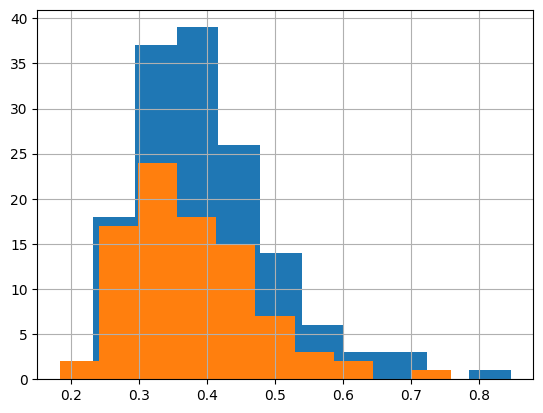

In [104]:
ak_MECFS.hist()
ak_Control.hist()

C:\Users\rohan\AppData\Local\Temp\ipykernel_13524\758932413.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ak_MECFS, ak_Control], labels=["MECFS", "Control"])


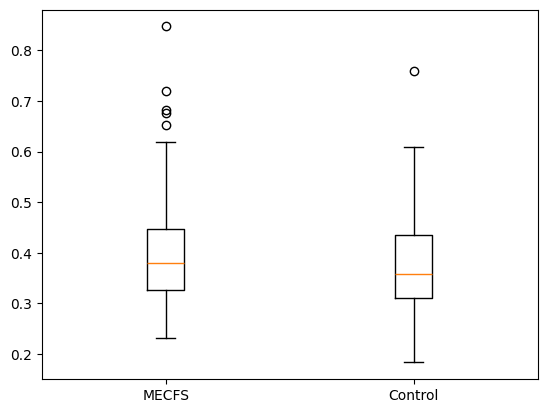

In [105]:
import matplotlib.pyplot as plt

plt.boxplot([ak_MECFS, ak_Control], labels=["MECFS", "Control"])
plt.show()